# **File Ingestion**

Pick a file of text data that is greater than 2 GB.
Kaggle:


Take any csv/text file of 2+ GB of your choice. --- (You can do this assignment on Google colab)

Read the file ( Present approach of reading the file )

Try different methods of file reading eg: Dask, Modin, Ray, pandas and present your findings in term of computational efficiency

Perform basic validation on data columns : eg: remove special character , white spaces from the col name

As you already know the schema hence create a YAML file and write the column name in YAML file. --define separator of read and write file, column name in YAML

Validate number of columns and column name of ingested file with YAML.

Write the file in pipe separated text file (|) in gz format.

Create a summary of the file:

Total number of rows,

total number of columns

file size

In [5]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Don't execute again we have this file now
# make a sequence database
import csv
import random
import os
import uuid
from google.colab import drive

# Mount Google Drive
# drive.mount('/content/drive')

# Define the sample characters
sample_chars = ['A', 'C', 'T', 'G', '   ', '$', '-', '&', '#']

# Define the target file size in bytes (3GB)
target_size_bytes = 3 * (1024**3)

# Generate the CSV file and save it to Google Drive
file_path = '/content/drive/My Drive/DATAGLACIER/sequences.csv'  # Update with your desired path
with open(file_path, 'w', newline='', encoding='utf-8') as csvfile:
    csvwriter = csv.writer(csvfile)

    # Write the header
    csvwriter.writerow(['Index', 'Sequence', 'Label'])

    # Write rows until the file size reaches the target
    file_size = 0
    i = 0
    while file_size < target_size_bytes:
        # Generate random sequence length between 50 and 1500
        row_size = random.randint(50, 1000)
        sequence = ''.join(random.choice(sample_chars) for _ in range(row_size))

        # Generate a unique label using UUID
        label = str(uuid.uuid4())

        csvwriter.writerow([i, sequence, label])

        # Update file size
        file_size = os.path.getsize(file_path)
        i += 1

print("sequence.csv file saved to Google Drive successfully!")


CSV file saved to Google Drive successfully!


In [6]:
# make a pandas dataframe for sequence.csv

import pandas as pd
sequence_df = pd.read_csv('/content/drive/My Drive/DATAGLACIER/sequences.csv')

#print index of sequence.csv
print(sequence_df.index)

print("sequence_df made successfully!")

#save sequence_df
sequence_df.to_csv('/content/drive/My Drive/DATAGLACIER/sequence_df.csv', index=True)


RangeIndex(start=0, stop=4680023, step=1)
sequence_df made successfully!


In [7]:
sequence_df.shape

(4680023, 3)

In [8]:
# Show the original data in each Sequence attribute row for head
sequence_df.head(10)


,Index,Sequence,Label
0,0,## G&#T$ T$TA -ACA&T--&#G GAG-GAA$&...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G -$ CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$#C...,b596cd78-6750-45cf-9324-1817093536bd
2,2,#TC$CT T TAT-G$ -$CC A-$GTGC $A ...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,#AC$ T# & C-C$A C#C#C&#-#G#GC-CGGA-...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,#TG-A- TT#$CAT$-$# &AA &# G ---CT--#...,f6b577bd-3ed2-46e5-847c-a06410c43c7a
5,5,-G#$ T-T-A&#& G -$$A#A#G$C- - C&T#--...,ce81c108-9081-4393-8805-3510101ed905
6,6,TG$ -#G#$&A-GT-A$G- #T$#&#$ T-G-#&GTG...,626f4163-7e3a-41d3-bd53-3cf9d5c5ac24
7,7,#CT#- $TG-T#G&$-- C-GG$ -$T$C-&C-$$ ...,2022bfa5-2c87-4fa9-ae8d-d202958ef93f
8,8,G #&A#&AA&&G$T- -$&#&- T#A-&T$GT#AT G$...,561f279d-5120-422f-b39f-c9b0dc775880
9,9,TTT #T&T#- CG-$A&C&CGGG # $GG&A C...,4c1ef8ba-9687-4844-b3e3-1259dc6ffae6


In [9]:
# Check the size in memory of sequence_df
sequence_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4680023 entries, 0 to 4680022
Data columns (total 3 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   Index     int64 
 1   Sequence  object
 2   Label     object
dtypes: int64(1), object(2)
memory usage: 3.5 GB


In [10]:
# Remove whitespace from each array '  ' in sequence_df
sequence_df['Sequence'] = sequence_df['Sequence'].str.replace(' ', '')
print("whitespace removed successfully!")

whitespace removed successfully!


In [11]:
# Check the sequences
sequence_df.head()


,Index,Sequence,Label
0,0,##G&#T$T$TA-ACA&T--&#GGAG-GAA$&GTC$##-C-$CG&A&...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-$CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$#C#--#&A...,b596cd78-6750-45cf-9324-1817093536bd
2,2,#TC$CTTTAT-G$-$CCA-$GTGC$A-ATGAT#G&G-A&GGT-CAG...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,#AC$T#&C-C$AC#C#C&#-#G#GC-CGGA-$T$GCGAGCC$T-C$...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,#TG-A-TT#$CAT$-$#&AA&#G---CT--#C--AG#$TAT&&$#A...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [12]:
# Remove the '#' from sequence_df ['Sequence']
sequence_df['Sequence'] = sequence_df['Sequence'].str.replace('#', '')
print("hashtag removed successfully!")

hashtag removed successfully!


In [13]:
# Show Hashtag is removed by looking the head
sequence_df.head()

,Index,Sequence,Label
0,0,G&T$T$TA-ACA&T--&GGAG-GAA$&GTC$-C-$CG&A&&TA&-T...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-$CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$C--&AT&A...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TC$CTTTAT-G$-$CCA-$GTGC$A-ATGATG&G-A&GGT-CAGAC...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,AC$T&C-C$ACCC&-GGC-CGGA-$T$GCGAGCC$T-C$&$ATTT$...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TG-A-TT$CAT$-$&AA&G---CT--C--AG$TAT&&$A-&-$T$&...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [14]:
# Remove the '$' from sequence_df ['Sequence']
sequence_df['Sequence'] = sequence_df['Sequence'].str.replace('$', '')
print("hashtag removed successfully!")

hashtag removed successfully!


In [15]:
# Check the head to see if $ removed successfully
sequence_df.head()

,Index,Sequence,Label
0,0,G&TTTA-ACA&T--&GGAG-GAA&GTC-C-CG&A&&TA&-TAT&&C...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-CGAT&ATA&&AC-&C&ACGGTTTG&G&TGGG-C--&AT&A&CG-...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTAT-G-CCA-GTGCA-ATGATG&G-A&GGT-CAGACGAAAC...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACT&C-CACCC&-GGC-CGGA-TGCGAGCCT-C&ATTT-CCC-GAC...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TG-A-TTCAT-&AA&G---CT--C--AGTAT&&A-&-T&-TCCTCA...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [16]:
# Remove the '-' from sequence_df ['Sequence']
sequence_df['Sequence'] = sequence_df['Sequence'].str.replace('-', '')
print("dash removed successfully!")

dash removed successfully!


In [17]:
# Check if dash was removed from Sequence
sequence_df.head()

,Index,Sequence,Label
0,0,G&TTTAACA&T&GGAGGAA&GTCCCG&A&&TA&TAT&&CTATCT&C...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,GCGAT&ATA&&AC&C&ACGGTTTG&G&TGGGC&AT&A&CGATA&A&...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTATGCCAGTGCAATGATG&GA&GGTCAGACGAAACTGAC&A...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACT&CCACCC&GGCCGGATGCGAGCCTC&ATTTCCCGACGC&AA&&...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TGATTCAT&AA&GCTCAGTAT&&A&T&TCCTCAA&TGTAAC&AACC...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [18]:
# Remove the '&' from sequence_df ['Sequence']
sequence_df['Sequence'] = sequence_df['Sequence'].str.replace('&', '')
print("ampersand removed successfully!")

ampersand removed successfully!


In [19]:
# check the removal of the & from Sequence
sequence_df.head()

,Index,Sequence,Label
0,0,GTTTAACATGGAGGAAGTCCCGATATATCTATCTCCATTTGTCGGG...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,GCGATATAACCACGGTTTGGTGGGCATACGATAACGCACTTTATAG...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTATGCCAGTGCAATGATGGAGGTCAGACGAAACTGACACTA...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACTCCACCCGGCCGGATGCGAGCCTCATTTCCCGACGCAAGCTCAC...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TGATTCATAAGCTCAGTATATTCCTCAATGTAACAACCCGTTTATT...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


###**Observations:**
Pandas Dataframe built in 1min20s

*   Pandas Data frame built in 1min20s
*   Size of the file: 3.5GB in 2s
*   4,680,023 rows 3 columns in 0s
*   Remove whitespace from Sequence 32s
*   Remove hashtag from Sequence 19s
*   Remove $ from Sequence 22s
*   Remove dash from Sequence 15s
*   Remove ampersand from Sequence 14s
*   df=['df_built','memory','rows','columns'
*   pandas =[80,2,0,32,19,22,15,14]










In [20]:
import pandas as pd
import numpy as np

comparison_df = pd.DataFrame(columns=['type', 'build_time','memory_time','row_time','column_time','whitespace_time','hashtag_time', 'dollar_time','dash_time', 'apersand_time'])

# Create a dictionary with the data for the 'pandas' row
pandas_data = {'type': 'pandas', 'build_time': 80, 'memory_time': 2, 'row_time': 3, 'column_time': 0, 'whitespace_time': 32, 'hashtag_time': 19, 'dollar_time': 22, 'dash_time': 15, 'apersand_time': 14}

print(pandas_data)

# comparison_df = comparison_df.append(pandas_data, ignore_index=True)

# Print the comparison DataFrame
# print(comparison_df)

{'type': 'pandas', 'build_time': 80, 'memory_time': 2, 'row_time': 3, 'column_time': 0, 'whitespace_time': 32, 'hashtag_time': 19, 'dollar_time': 22, 'dash_time': 15, 'apersand_time': 14}


In [ ]:
# Make YAML file
import yaml

# Define the YAML file path
yaml_file_path = '/content/drive/My Drive/DATAGLACIER/config.yaml'

# Define the YAML content
yaml_content = {
    'file_type': 'csv',
    'dataset_name': 'sequence.csv'
    'file_name': 'sequence.csv',
    'inbound_delimiter': ',',
    'outbound_delimiter': '|',
    'skip_leading_rows': 1,
    'columns': ['Index', 'Sequence', 'Label']
}
# print yaml file made
print(yaml_content)

# Write the YAML content to the file
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(yaml_content, yaml_file)

SyntaxError: invalid syntax (<ipython-input-15-487c0ba2e512>, line 11)

# **VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV**

In [21]:
# Read Files with Dask
from dask import dataframe as dd
dask_sequence_df = dd.read_csv('/content/drive/My Drive/DATAGLACIER/sequences.csv')
print("dask sequence_df made successfully!")

dask sequence_df made successfully!


Observations for Dask



*   Dask dataframe made in 3s
*   Memory usage 3.1 GB in 45s
*   dask_sequence_df_head() 1s
*   Number of rows 34s
*   Number of columns 0s
*   Remove whitespace 5s
*   When checking the whitespace removal, all special characters and whitespace was removed and it took 45s
*   List item









In [22]:
# Create a dictionary with the data for the 'pandas' row
dask_data = {'type': 'dask', 'build_time': 3, 'memory_time':45, 'row_time': 34, 'column_time': 0, 'whitespace_time': 5, 'hashtag_time': 0, 'dollar_time': 0, 'dash_time': 0, 'apersand_time': 0}

print(dask_data)

{'type': 'dask', 'build_time': 3, 'memory_time': 45, 'row_time': 34, 'column_time': 0, 'whitespace_time': 5, 'hashtag_time': 0, 'dollar_time': 0, 'dash_time': 0, 'apersand_time': 0}


In [23]:
# Check the size in memory of sequence_df
dask_sequence_df.info(memory_usage='deep')

<class 'dask_expr.DataFrame'>
Columns: 3 entries, Index to Label
dtypes: int64(1), string(2)
memory usage: 3.1 GB


In [24]:
dask_sequence_df.head()

,Index,Sequence,Label
0,0,## G&#T$ T$TA -ACA&T--&#G GAG-GAA$&...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G -$ CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$#C...,b596cd78-6750-45cf-9324-1817093536bd
2,2,#TC$CT T TAT-G$ -$CC A-$GTGC $A ...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,#AC$ T# & C-C$A C#C#C&#-#G#GC-CGGA-...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,#TG-A- TT#$CAT$-$# &AA &# G ---CT--#...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [25]:
dask_sequence_df.shape

(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(55e5894)).size() // 3, dtype=int64>,
 3)

In [26]:
# Get the number of rows of dask_sequence_df
num_rows = len(dask_sequence_df.index)
print(f"Number of rows: {num_rows}")

Number of rows: 4680023


In [27]:
# Get the number of columns of dask_sequence_df
num_columns = len(dask_sequence_df.columns)
print(f"Number of columns: {num_columns}")

Number of columns: 3


In [28]:
# Remove whitespace from each array '  ' in sequence_df
dask_sequence_df['Sequence'] = sequence_df['Sequence'].str.replace(' ', '')
print("whitespace removed successfully")

whitespace removed successfully


In [29]:
#Check the whitespace in Sequence
dask_sequence_df.head()

,Index,Sequence,Label
3,1405850,ACTCCACCCGGCCGGATGCGAGCCTCATTTCCCGACGCAAGCTCAC...,2dddd214-0e05-4881-97b0-e9e8fc2b68ca
54,1405901,AATACCTGGGCAACTGTTGGTCGCAGCCACGGATTGAAAGCATTGA...,0118ba53-0866-4be9-a037-0880346a279d
89,1405936,GGGGATTTGATCAATCCATACGGTACTTCCAGCAGGAGTTTTACAG...,3c17107e-6f1d-4ff0-8fec-6bfb7ab7e0b4
122,1405969,TAATAGGCATCATCAGTACAGCGCATCTGGCACGGACTGTCCACCA...,e15f0a8e-4d82-48f0-92b5-229b7281f62c
173,1406020,CTTACTCAATTACAACTGTCGGGTACGCCTCGTGATCAACCCTACG...,36f45525-f241-4b49-93f3-c5c1f671c6e0


In [30]:
!pip install modin[ray]
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.3 MB/s eta 0:00:00


In [31]:
#verify path
import os
print(os.getcwd())

# verify path '/content/drive/My Drive/DATAGLACIER/sequence.csv'exsists
print(os.path.exists('/content/drive/My Drive/DATAGLACIER/sequences.csv'))

/content
True


In [32]:
import modin.pandas as pd
import ray

# Initialize Ray with specific resources if needed
ray.init(num_cpus=4)  # Example: Set the number of CPUs to use

# Read the CSV file into a Modin DataFrame
modin_sequence_df = pd.read_csv('/content/drive/My Drive/DATAGLACIER/sequences.csv')
print("modin sequence_df made successfully!")

2025-03-13 05:05:58,507	INFO worker.py:1841 -- Started a local Ray instance.


modin sequence_df made successfully!


In [33]:
#Check Shape
modin_sequence_df.shape

(4680023, 3)

In [34]:
# Check the size in memory of sequence_df
modin_sequence_df.info(memory_usage='deep')

<class 'modin.pandas.dataframe.DataFrame'>
RangeIndex: 4680023 entries, 0 to 4680022
Data columns (total 3 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   Index     int64 
 1   Sequence  object
 2   Label     object
dtypes: int64(1), object(2)
memory usage: 3.5 GB


In [35]:
## Remove whitespace from each array '  ' in sequence_df
modin_sequence_df['Sequence'] = modin_sequence_df['Sequence'].str.replace(' ', '')
print("whitespace removed successfully!")

whitespace removed successfully!


In [36]:
modin_sequence_df.head()

,Index,Sequence,Label
0,0,##G&#T$T$TA-ACA&T--&#GGAG-GAA$&GTC$##-C-$CG&A&...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-$CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$#C#--#&A...,b596cd78-6750-45cf-9324-1817093536bd
2,2,#TC$CTTTAT-G$-$CCA-$GTGC$A-ATGAT#G&G-A&GGT-CAG...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,#AC$T#&C-C$AC#C#C&#-#G#GC-CGGA-$T$GCGAGCC$T-C$...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,#TG-A-TT#$CAT$-$#&AA&#G---CT--#C--AG#$TAT&&$#A...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [37]:
## Remove hashtag from each array '#' in sequence_df
modin_sequence_df['Sequence'] = modin_sequence_df['Sequence'].str.replace('#', '')
print("hashtag removed successfully!")

hashtag removed successfully!


In [38]:
modin_sequence_df.head()


,Index,Sequence,Label
0,0,G&T$T$TA-ACA&T--&GGAG-GAA$&GTC$-C-$CG&A&&TA&-T...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-$CGAT&$ATA&&AC-&C&ACGGTT$TG&G&TGGG-$C--&AT&A...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TC$CTTTAT-G$-$CCA-$GTGC$A-ATGATG&G-A&GGT-CAGAC...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,AC$T&C-C$ACCC&-GGC-CGGA-$T$GCGAGCC$T-C$&$ATTT$...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TG-A-TT$CAT$-$&AA&G---CT--C--AG$TAT&&$A-&-$T$&...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [39]:
## Remove $ from each array '$' in sequence_df
modin_sequence_df['Sequence'] = modin_sequence_df['Sequence'].str.replace('$', '')
print("$ removed successfully!")

$ removed successfully!


In [40]:
modin_sequence_df.head()

,Index,Sequence,Label
0,0,G&TTTA-ACA&T--&GGAG-GAA&GTC-C-CG&A&&TA&-TAT&&C...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,G-CGAT&ATA&&AC-&C&ACGGTTTG&G&TGGG-C--&AT&A&CG-...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTAT-G-CCA-GTGCA-ATGATG&G-A&GGT-CAGACGAAAC...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACT&C-CACCC&-GGC-CGGA-TGCGAGCCT-C&ATTT-CCC-GAC...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TG-A-TTCAT-&AA&G---CT--C--AGTAT&&A-&-T&-TCCTCA...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [41]:
## Remove dash from each array '-' in sequence_df
modin_sequence_df['Sequence'] = modin_sequence_df['Sequence'].str.replace('-', '')
print("dash removed successfully!")

dash removed successfully!


In [42]:
modin_sequence_df.head()

,Index,Sequence,Label
0,0,G&TTTAACA&T&GGAGGAA&GTCCCG&A&&TA&TAT&&CTATCT&C...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,GCGAT&ATA&&AC&C&ACGGTTTG&G&TGGGC&AT&A&CGATA&A&...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTATGCCAGTGCAATGATG&GA&GGTCAGACGAAACTGAC&A...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACT&CCACCC&GGCCGGATGCGAGCCTC&ATTTCCCGACGC&AA&&...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TGATTCAT&AA&GCTCAGTAT&&A&T&TCCTCAA&TGTAAC&AACC...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


In [43]:
## Remove & from each array '&' in sequence_df
modin_sequence_df['Sequence'] = modin_sequence_df['Sequence'].str.replace('&', '')
print("ampersand removed successfully!")

ampersand removed successfully!


In [44]:
modin_sequence_df.head()

,Index,Sequence,Label
0,0,GTTTAACATGGAGGAAGTCCCGATATATCTATCTCCATTTGTCGGG...,2259c0ad-cece-442f-a8ce-1b430ddb6ac7
1,1,GCGATATAACCACGGTTTGGTGGGCATACGATAACGCACTTTATAG...,b596cd78-6750-45cf-9324-1817093536bd
2,2,TCCTTTATGCCAGTGCAATGATGGAGGTCAGACGAAACTGACACTA...,34608e14-54e4-4c10-b64b-abd98f50e8e3
3,3,ACTCCACCCGGCCGGATGCGAGCCTCATTTCCCGACGCAAGCTCAC...,4efe175c-bdec-43c1-88ea-f933163eb242
4,4,TGATTCATAAGCTCAGTATATTCCTCAATGTAACAACCCGTTTATT...,f6b577bd-3ed2-46e5-847c-a06410c43c7a


###**Observations:**
Modin Dataframe with Ray backend  built in 1min20s

*   Modin Data frame built in 44s
*   Size of the file: 3.5GB in 1s
*   4,680,023 rows 3 columns in 0s
*   Remove whitespace from Sequence 0s
*   Remove hashtag from Sequence 0s
*   Remove $ from Sequence 0s
*   Remove dash from Sequence 0s
*   Remove ampersand from Sequence 0s
*   List item

In [45]:
# Create a dictionary with the data for the 'pandas' row
modin_data = {'type': 'modin', 'build_time': 44, 'memory_time':1, 'row_time': 0, 'column_time': 0, 'whitespace_time': 0, 'hashtag_time': 0, 'dollar_time': 0, 'dash_time': 0, 'apersand_time': 0}

print(modin_data)

{'type': 'modin', 'build_time': 44, 'memory_time': 1, 'row_time': 0, 'column_time': 0, 'whitespace_time': 0, 'hashtag_time': 0, 'dollar_time': 0, 'dash_time': 0, 'apersand_time': 0}


In [46]:
import pandas as pd
# concatenate pandas_data, dask_data, and modin_data
comparison_df = pd.concat([comparison_df, pd.DataFrame([pandas_data, dask_data, modin_data])], ignore_index=True)
print(comparison_df)

     type build_time memory_time row_time column_time whitespace_time  \
0  pandas         80           2        3           0              32   
1    dask          3          45       34           0               5   
2   modin         44           1        0           0               0   

  hashtag_time dollar_time dash_time apersand_time  
0           19          22        15            14  
1            0           0         0             0  
2            0           0         0             0  


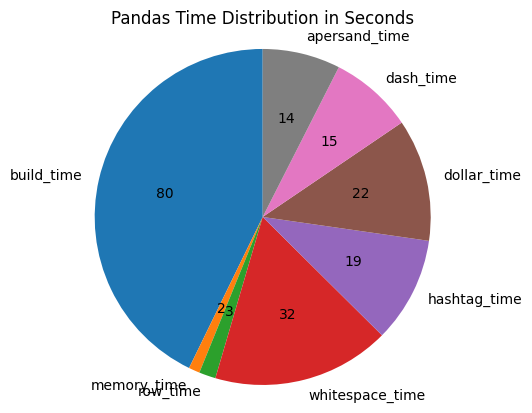

In [64]:
# make a pie chart for pandas_data
# zero data removed for clarity
import matplotlib.pyplot as plt

pandas_data = {'type': 'pandas', 'build_time': 80, 'memory_time': 2, 'row_time': 3, 'whitespace_time': 32, 'hashtag_time': 19, 'dollar_time': 22, 'dash_time': 15, 'apersand_time': 14}

# Prepare the data for the pie chart
labels = list(pandas_data.keys())[1:]  # Exclude the 'type' key
sizes = list(pandas_data.values())[1:]

# Create the pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_autopct
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=90)


plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Pandas Time Distribution in Seconds')


plt.show()

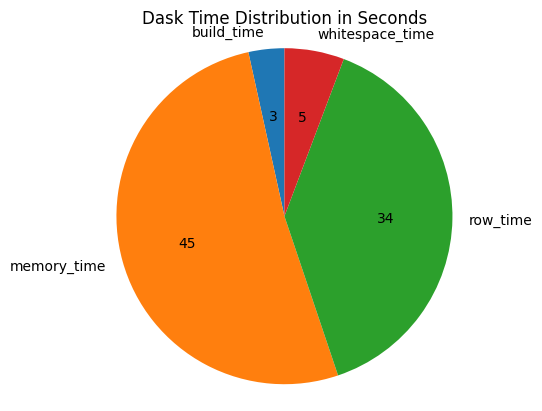

In [65]:
# make a pie chart for dask_data
import matplotlib.pyplot as plt

dask_data = {'type': 'dask', 'build_time': 3, 'memory_time':45, 'row_time': 34, 'whitespace_time': 5}

# Prepare the data for the pie chart
labels = list(dask_data.keys())[1:]  # Exclude the 'type' key
sizes = list(dask_data.values())[1:]

# Create the pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_autopct
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=90)


plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Dask Time Distribution in Seconds')


plt.show()

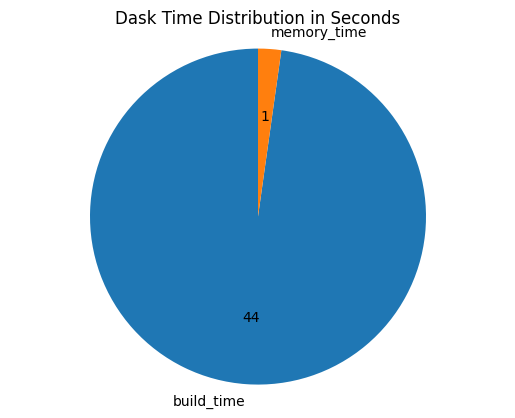

In [67]:
# make a pie chart for modin_data
import matplotlib.pyplot as plt

modin_data = {'type': 'modin', 'build_time': 44, 'memory_time':1}

# Prepare the data for the pie chart
labels = list(modin_data.keys())[1:]  # Exclude the 'type' key
sizes = list(modin_data.values())[1:]

# Create the pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_autopct
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes), startangle=90)


plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Dask Time Distribution in Seconds')


plt.show()

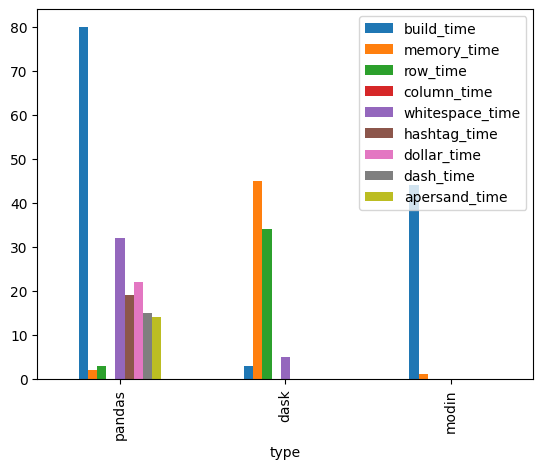

In [47]:
# make a barchart plot for comparison_df
import matplotlib.pyplot as plt
comparison_df.plot(x='type', y=['build_time','memory_time','row_time','column_time','whitespace_time','hashtag_time', 'dollar_time','dash_time', 'apersand_time'], kind='bar')
plt.show()


In [68]:
import yaml

# Define the YAML file path
yaml_file_path = '/content/drive/My Drive/DATAGLACIER/sequence_df.yaml'  # Update with your desired path

# Define the YAML content based on sequence_df's schema
yaml_content = {
    'file_type': 'csv',
    'dataset_name': 'sequence_df',
    'file_name': 'sequence_df.csv',  # Assuming you saved it as 'sequence_df.csv'
    'inbound_delimiter': ',',
    'outbound_delimiter': '|',
    'skip_leading_rows': 1,  # If there's a header row
    'columns': ['Index', 'Sequence', 'Label']  # Columns of sequence_df
}

# Write the YAML content to the file
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(yaml_content, yaml_file)

print(f"YAML file created successfully at: {yaml_file_path}")


YAML file created successfully at: /content/drive/My Drive/DATAGLACIER/sequence_df.yaml


In [71]:
import yaml
import gzip

# Load the YAML file
yaml_file_path = '/content/drive/My Drive/DATAGLACIER/sequence_df.yaml'
with open(yaml_file_path, 'r') as yaml_file:
    yaml_data = yaml.safe_load(yaml_file)

# Extract the data to be written
data_to_write = [yaml_data['file_type'], yaml_data['dataset_name'], yaml_data['file_name'],
                 yaml_data['inbound_delimiter'], yaml_data['outbound_delimiter'],
                 yaml_data['skip_leading_rows'], '|'.join(yaml_data['columns'])]  # Join columns with '|'

# Define the output file path
output_file_path = '/content/drive/My Drive/DATAGLACIER/sequence_df.txt.gz'  # Update if needed

# Write to the gzip compressed file
with gzip.open(output_file_path, 'wt', encoding='utf-8') as gz_file:
    gz_file.write('|'.join(map(str, data_to_write)))  # Join data with '|' and write

print(f"Data written to gzip compressed file: {output_file_path}")

Data written to gzip compressed file: /content/drive/My Drive/DATAGLACIER/sequence_df.txt.gz


In [72]:
import yaml

# Load the YAML file
yaml_file_path = '/content/drive/My Drive/DATAGLACIER/sequence_df.yaml'
with open(yaml_file_path, 'r') as yaml_file:
    yaml_data = yaml.safe_load(yaml_file)

# Get the column names
column_names = yaml_data['columns']

# Get the number of columns
num_columns = len(column_names)

# Print the results
print("Column Names:", column_names)
print("Number of Columns:", num_columns)




Column Names: ['Index', 'Sequence', 'Label']
Number of Columns: 3


In [73]:
import os

# Define the YAML file path
yaml_file_path = '/content/drive/My Drive/DATAGLACIER/sequence_df.yaml'  # Update with your desired path

# Get the file size in bytes
file_size = os.path.getsize(yaml_file_path)

# Print the file size
print("File Size (bytes):", file_size)

File Size (bytes): 172
